# Credit Card Fraud Detection using Machine Learning

---

# Business Understanding

## Problem Statement

Credit card fraud has become one of the most significant challenges faced by financial institutions worldwide. Every fraudulent transaction results in financial losses for banks and merchants while also negatively impacting customer trust and satisfaction.

The objective of this project is to build a machine learning model capable of accurately identifying fraudulent credit card transactions.

Unlike traditional binary classification problems, fraud detection presents several unique challenges:

- The dataset is **extremely imbalanced**, with fraudulent transactions accounting for only **0.172%** of all observations.
- Missing a fraudulent transaction (False Negative) is usually much more expensive than incorrectly flagging a legitimate transaction (False Positive).
- Conventional evaluation metrics such as Accuracy become misleading because a model predicting every transaction as legitimate would still achieve more than **99.8% accuracy**.

Therefore, this project emphasizes metrics such as:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall AUC (Primary Metric)

rather than relying solely on accuracy.

---

# Objectives

The primary objectives of this project are:

1. Perform extensive Exploratory Data Analysis (EDA).
2. Understand transaction behaviour.
3. Identify important predictive features.
4. Engineer meaningful features.
5. Handle severe class imbalance.
6. Compare multiple machine learning algorithms.
7. Perform hyperparameter tuning.
8. Analyse model errors.
9. Provide business recommendations based on the results.

---

# Dataset Description

The dataset contains credit card transactions made by European cardholders during September 2013.

### Dataset Statistics

|Property|Value|
|---------|------|
|Transactions|284,807|
|Fraud Transactions|492|
|Legitimate Transactions|284,315|
|Fraud Percentage|0.172%|

### Features

The dataset consists of 31 columns.

- **Time** : Seconds elapsed between each transaction and the first transaction.
- **Amount** : Transaction amount.
- **V1–V28** : Principal Components obtained after applying PCA.
- **Class** : Target Variable.

Target values:

- 0 → Legitimate Transaction
- 1 → Fraudulent Transaction

---

# Import Required Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Load Dataset

In [7]:
df = pd.read_csv("Dataset/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


# Dataset Dimensions

In [8]:
print("DATASET DIMENSIONS")

print(f"Number of Rows      : {df.shape[0]:,}")
print(f"Number of Columns   : {df.shape[1]}")

DATASET DIMENSIONS
Number of Rows      : 284,807
Number of Columns   : 31


## Observation

The dataset contains nearly **285 thousand transactions**, making it sufficiently large for training machine learning models while remaining computationally manageable on consumer hardware.

Among the 31 variables, 30 are predictor variables and one is the target variable (`Class`).

# Dataset Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Observation

From the dataset information, we observe:

- Every feature is numerical.
- No categorical variables are present.
- The target variable (`Class`) is stored as an integer.
- Most predictor variables are floating-point numbers.
- The dataset occupies a manageable amount of memory.
- The dataset does not contain null values.

Since all features are already numeric, no categorical encoding techniques such as One-Hot Encoding or Label Encoding are required.

# Descriptive Statistics

Descriptive statistics summarize the numerical characteristics of each feature.

Important statistics include:

- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These statistics help identify:

- Outliers
- Skewed distributions
- Scaling requirements
- Data quality issues

In [13]:
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


## Initial Observations

### Time

The **Time** feature ranges from **0 seconds** to approximately **172,792 seconds**, confirming that the dataset spans nearly **48 hours** of transaction activity.

---

### Amount

The **Amount** feature exhibits a large gap between its median and maximum value, indicating a highly **right-skewed distribution**.

This suggests the presence of significant outliers and indicates that **RobustScaler** may be more suitable than StandardScaler during preprocessing.

---

### PCA Features

Features **V1–V28** are principal components generated using Principal Component Analysis (PCA).

Since PCA typically produces standardized components with means close to zero and similar variances, these features generally do not require additional scaling.

# Missing Value Analysis

In [15]:
# Number of missing values in each feature

missing_values = df.isnull().sum()

# Total missing values

total_missing = missing_values.sum()

print("TOTAL MISSING VALUES")

print(total_missing)

TOTAL MISSING VALUES
0


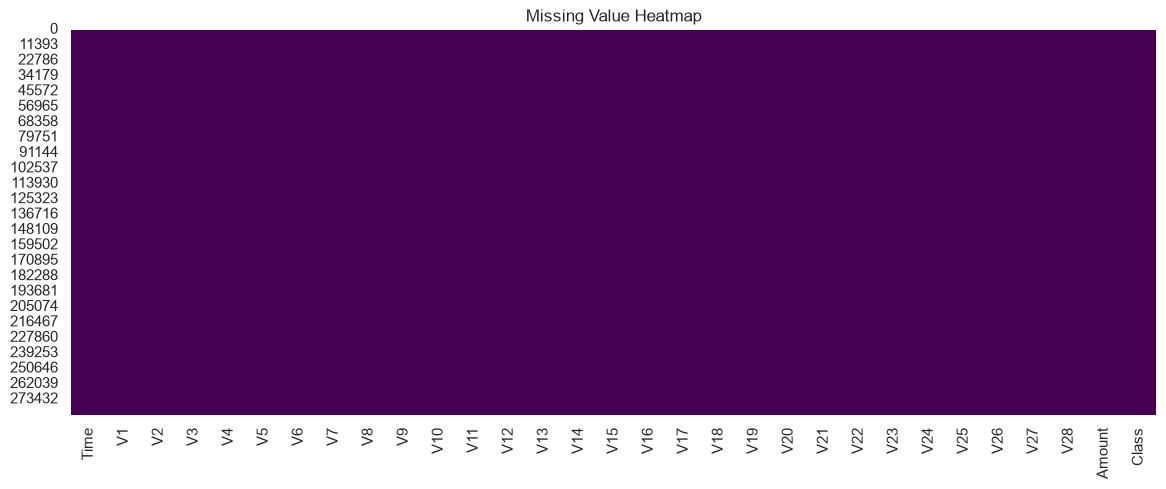

In [16]:
# Visualize Missing Values

plt.figure(figsize=(14,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

## Observation

The analysis reveals that **no missing values** are present in the dataset.

This is a significant advantage because:

- No imputation techniques are required.
- No observations need to be discarded.
- The integrity of the original dataset is preserved.

# Duplicate Record Analysis
Duplicate transactions may bias machine learning models by artificially increasing the frequency of certain observations.

In [17]:
duplicate_rows = df.duplicated().sum()

print("DUPLICATE RECORDS")
print(f"Duplicate Rows : {duplicate_rows}")

DUPLICATE RECORDS
Duplicate Rows : 1081


In [18]:
duplicate_percentage = duplicate_rows/len(df)*100
print(f"Duplicate Percentage : {duplicate_percentage:.4f}%")

Duplicate Percentage : 0.3796%


In [19]:
# Display duplicate transactions
duplicates = df[df.duplicated()]
duplicates.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0000,-0.5299,0.8739,1.3472,0.1455,0.4142,0.1002,0.7112,0.1761,-0.2867,-0.4847,0.8725,0.8516,-0.5717,0.1010,-1.5198,-0.2844,-0.3105,-0.4042,-0.8234,-0.2903,0.0469,0.2081,-0.1855,0.0010,0.0988,-0.5529,-0.0733,0.0233,6.1400,0
35,26.0000,-0.5354,0.8653,1.3511,0.1476,0.4337,0.0870,0.6930,0.1797,-0.2856,-0.4825,0.8718,0.8534,-0.5718,0.1023,-1.5200,-0.2859,-0.3096,-0.4039,-0.8237,-0.2833,0.0495,0.2065,-0.1871,0.0008,0.0981,-0.5535,-0.0783,0.0254,1.7700,0
113,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
114,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0
115,74.0000,1.0384,0.1275,0.1845,1.1099,0.4417,0.9453,-0.0367,0.3510,0.1189,-0.2433,0.5781,0.6747,-0.5342,0.4466,1.1229,-1.7680,1.2412,-2.4495,-1.7473,-0.3355,0.1025,0.6051,0.0231,-0.6265,0.4791,-0.1669,0.0812,0.0012,1.1800,0


In [20]:
# Fraud distribution among duplicate rows
duplicates["Class"].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

## Observation

The dataset contains duplicate observations.

However, before removing them, it is important to understand whether they correspond to:

- legitimate repeated transactions, or
- duplicated entries introduced during data collection.

Blindly removing duplicate rows may accidentally remove valid fraudulent transactions, which are already extremely rare.

For the purpose of this project, the duplicate records will be retained to preserve potentially valuable fraud patterns.

# Target Variable Analysis

In [21]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [22]:
class_percentage = df["Class"].value_counts(normalize=True)*100
class_percentage

Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64

In [23]:
class_summary = pd.DataFrame({
    "Count":class_counts,
    "Percentage":class_percentage
})

class_summary

,Count,Percentage
Class,,
0,284315,99.8273
1,492,0.1727


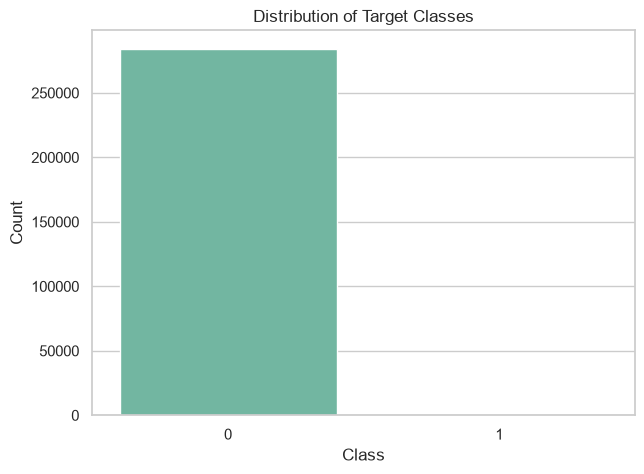

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

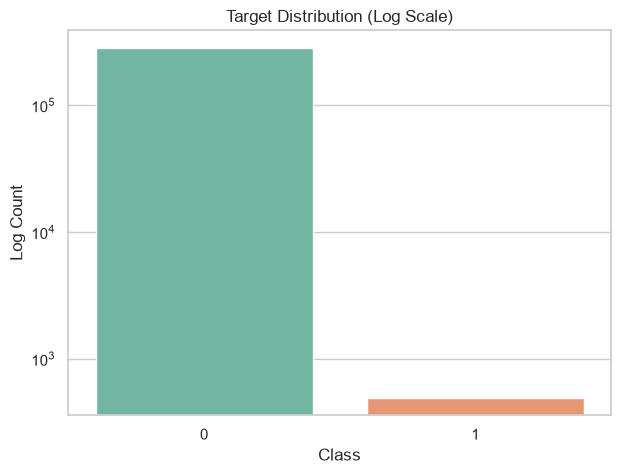

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

plt.yscale("log")
plt.title("Target Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Log Count")
plt.show()

## Observation

The dataset is **extremely imbalanced**.

Approximately:

- **99.828%** of transactions are legitimate.
- **0.172%** are fraudulent.

This imbalance has important implications for model development:

1. Accuracy is not an appropriate evaluation metric.

A naive classifier predicting every transaction as legitimate would achieve nearly **99.8% accuracy** while completely failing to detect fraud.

2. The minority class must be handled carefully during training.

Techniques such as **SMOTE**, class weighting, or other resampling strategies will be explored later in the project.

3. Model performance should be evaluated using metrics that focus on the minority class, including:

- Precision
- Recall
- F1-score
- ROC-AUC
- **Precision-Recall AUC (Primary Metric)**

These metrics provide a much more meaningful assessment of fraud detection performance than overall accuracy.

# Exploratory Data Analysis(EDA)

# Distribution of Transaction Amount
The **Amount** feature represents the monetary value of each transaction.

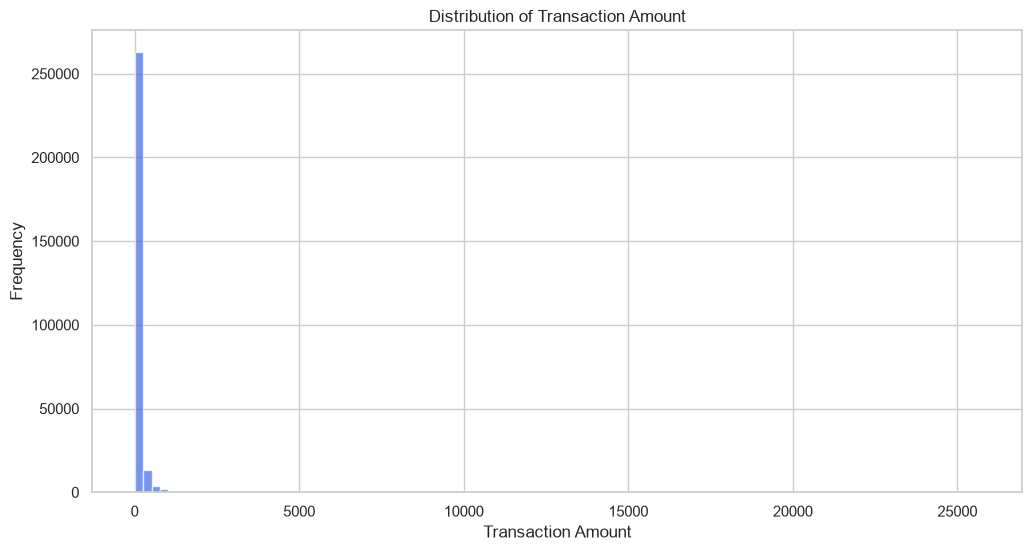

In [27]:
plt.figure(figsize=(12,6))

plt.hist(df["Amount"], bins=100, color="royalblue", alpha=0.7)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

## Observation

The distribution is **highly right-skewed**.

Key observations include:

- Most transactions involve relatively small amounts.
- Only a few transactions correspond to very large monetary values.
- Several extreme outliers are present.

This skewness indicates that the **mean is not a robust measure of central tendency** for this feature.

Furthermore, the presence of extreme values suggests that **RobustScaler** is likely to perform better than StandardScaler during preprocessing.

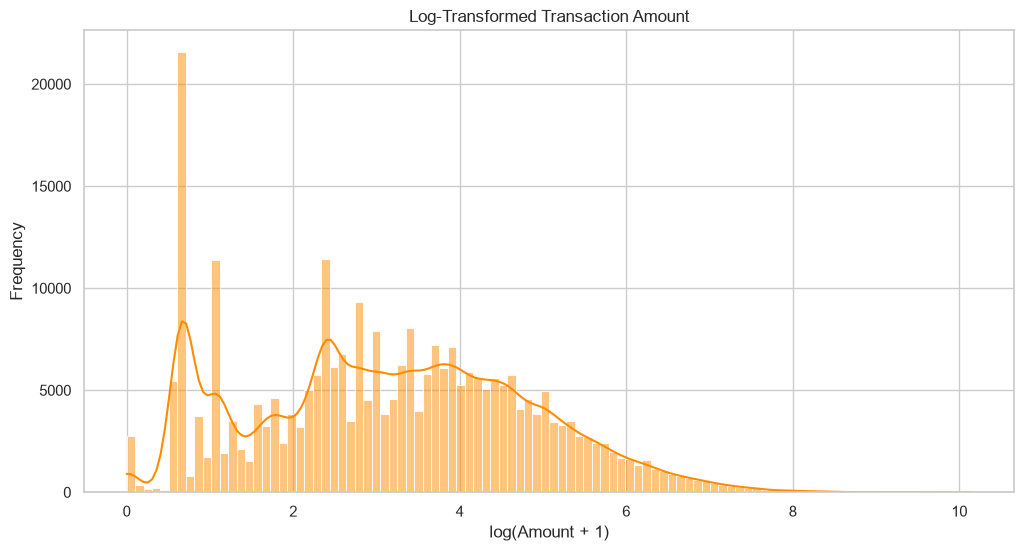

In [31]:
# Log Transformation of Transaction Amount

plt.figure(figsize=(12,6))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=100,
    kde=True,
    color="darkorange"
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

## Observation

The logarithmic transformation significantly reduces skewness.

Although the transformed feature is **not used directly at this stage**, this visualization confirms that the original Amount feature contains substantial positive skewness.

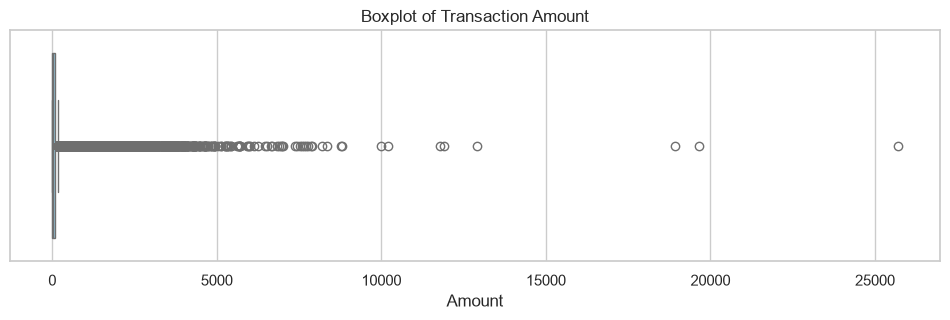

In [32]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Amount"],
    color="skyblue"
)

plt.title("Boxplot of Transaction Amount")

plt.show()

## Observation

The boxplot confirms the presence of a large number of extreme outliers.

However, these observations should **not** be removed without careful consideration.

In fraud detection, unusually large transactions may represent genuine fraud patterns.

# Distribution of Transaction Time
The **Time** feature represents the number of seconds elapsed since the first recorded transaction.

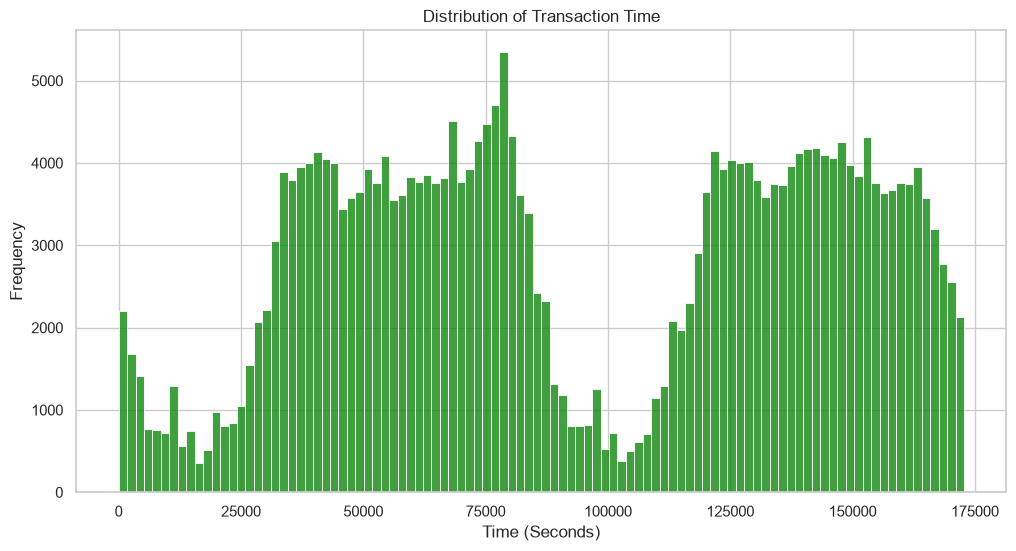

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    bins=100,
    color="green"
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency")
plt.show()

## Observation

Transactions occur throughout the entire two-day period.

The distribution suggests that transaction frequency varies over time, which may correspond to normal daily activity cycles.

Since Time is measured in seconds, it is difficult to interpret directly.

Therefore, we will engineer a more meaningful feature representing the **hour of the day**.

# Feature Engineering: Hour of Transaction

The original Time variable is difficult to interpret.

To improve interpretability, we create a new feature:

**Hour = Time / 3600**

This converts elapsed seconds into approximate hours.

Although the dataset spans two consecutive days, hourly transaction behaviour may still reveal useful fraud patterns.

In [35]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour"] = df["Hour"].astype(int)
df[["Time","Hour"]].head()

,Time,Hour
0,0.0000,0
1,0.0000,0
2,1.0000,0
3,1.0000,0
4,2.0000,0


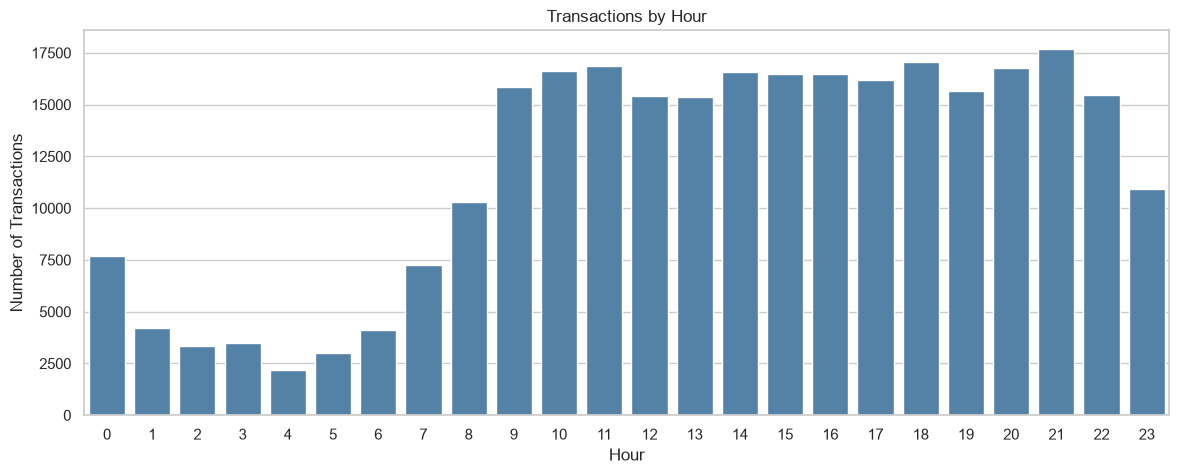

In [36]:
plt.figure(figsize=(14,5))

sns.countplot(
    data=df,
    x="Hour",
    color="steelblue"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()

## Observation

Transaction activity varies considerably throughout the day.

Certain hours exhibit significantly higher transaction volumes, likely reflecting normal customer behaviour.

# Fraudulent Transactions by Hour

This visualization compares the number of legitimate and fraudulent transactions occurring during each hour.

The objective is to determine whether fraud is concentrated during specific periods of the day.

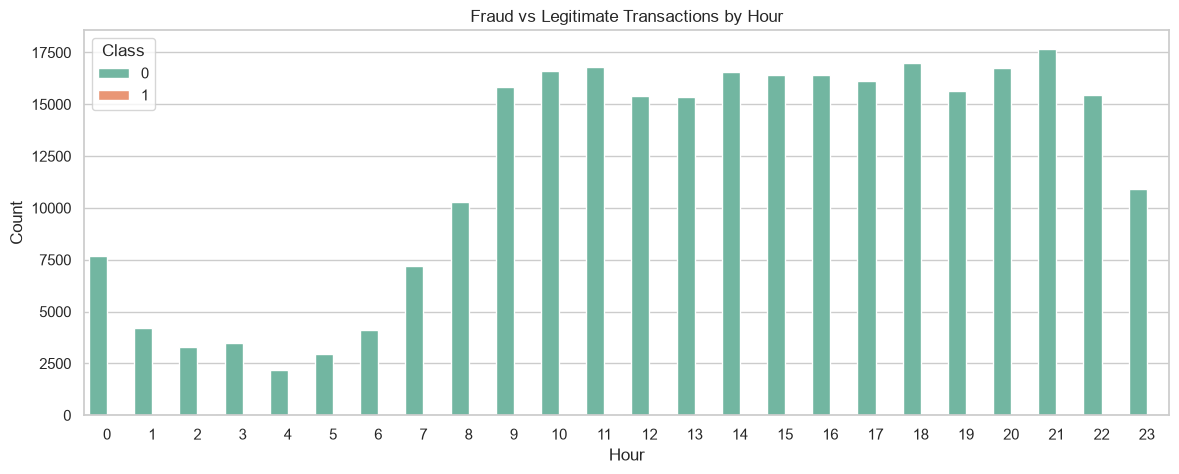

In [37]:
plt.figure(figsize=(14,5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class",
    palette="Set2"
)

plt.title("Fraud vs Legitimate Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# Class-wise Distribution of Transaction Amount

A key business question is whether fraudulent transactions generally involve higher monetary values.

To investigate this, we compare the transaction amounts across the two classes.

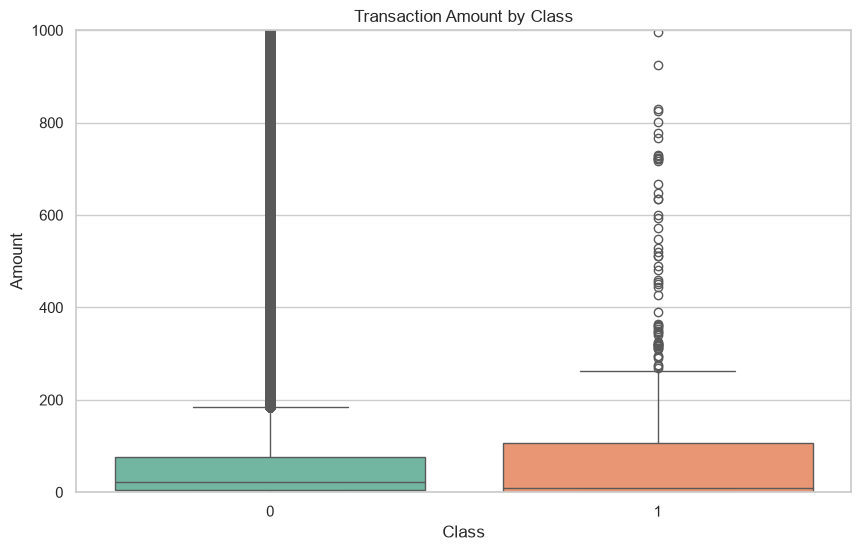

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    palette="Set2"
)

plt.ylim(0,1000)
plt.title("Transaction Amount by Class")
plt.show()

In [39]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0000,88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,25691.1600
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,2125.8700


# Correlation Analysis

Correlation analysis helps us understand the strength and direction of the linear relationship between variables.

Although the features in this dataset have been transformed using Principal Component Analysis (PCA), examining their correlations still provides valuable insights.
It is important to note that PCA produces orthogonal components, meaning strong correlations between the transformed variables are generally not expected.

# Correlation Matrix

The first step is to compute the correlation matrix for all numerical variables.

This matrix shows the Pearson correlation coefficient between every pair of variables.

Values close to:

- **+1** indicate a strong positive relationship.
- **−1** indicate a strong negative relationship.
- **0** indicate little or no linear relationship.

In [40]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
Time,1.0000,0.1174,-0.0106,-0.4196,-0.1053,0.1731,-0.0630,0.0847,-0.0369,-0.0087,0.0306,-0.2477,0.1243,-0.0659,-0.0988,-0.1835,0.0119,-0.0733,0.0904,0.0290,-0.0509,0.0447,0.1441,0.0511,-0.0162,-0.2331,-0.0414,-0.0051,-0.0094,-0.0106,-0.0123,0.4156
V1,0.1174,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2277,-0.1013,-0.0052
V2,-0.0106,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.5314,0.0913,0.0078
V3,-0.4196,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2109,-0.1930,-0.0216
V4,-0.1053,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0987,0.1334,-0.0351


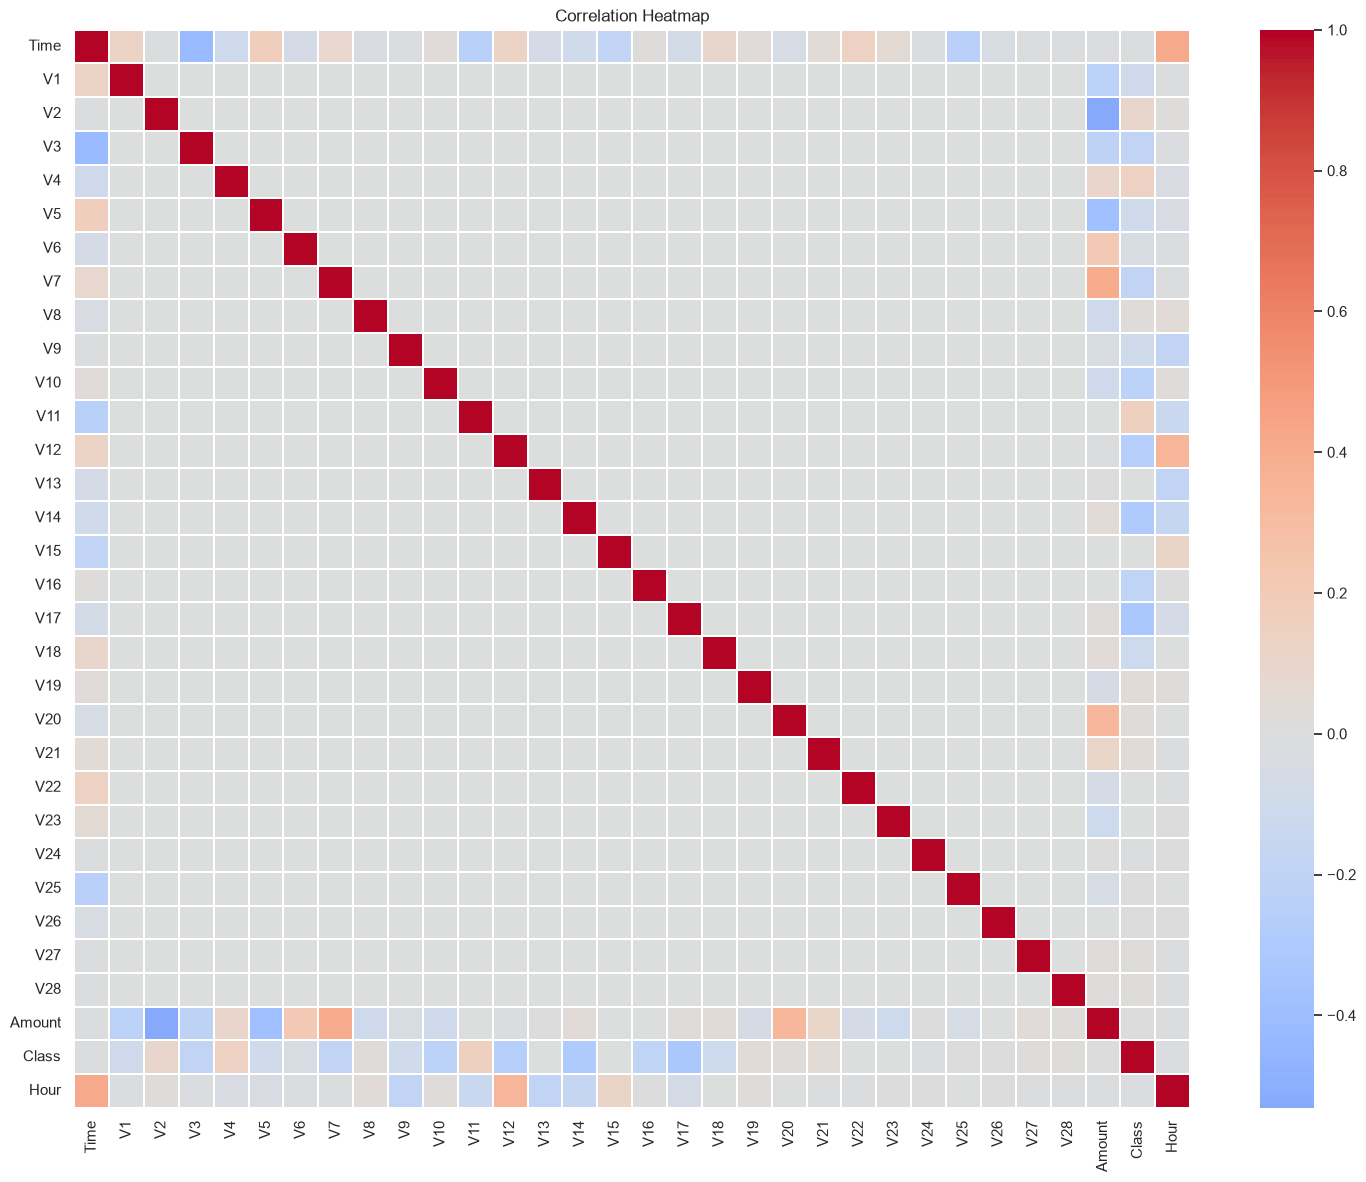

In [41]:
plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap")
plt.show()

## Observation

The correlation heatmap reveals relatively weak relationships among most predictor variables.

This behaviour is expected because the features V1–V28 are principal components obtained through PCA.

One of the objectives of PCA is to transform correlated variables into approximately orthogonal (uncorrelated) components.

Consequently:

- Multicollinearity is substantially reduced.
- Linear models such as Logistic Regression become more stable.
- Feature redundancy is minimized.

# Correlation with the Target Variable

Rather than studying relationships among predictors, we are primarily interested in identifying variables that are associated with fraudulent transactions.

The following analysis ranks every feature according to its correlation with the target variable (`Class`).

Although correlation alone does not determine predictive importance, it provides an excellent starting point for feature investigation.

In [42]:
target_corr = corr_matrix["Class"].sort_values()
target_corr

V17      -0.3265
V14      -0.3025
V12      -0.2606
V10      -0.2169
V16      -0.1965
V3       -0.1930
V7       -0.1873
V18      -0.1115
V1       -0.1013
V9       -0.0977
V5       -0.0950
V6       -0.0436
Hour     -0.0171
Time     -0.0123
V24      -0.0072
V13      -0.0046
V15      -0.0042
V23      -0.0027
V22       0.0008
V25       0.0033
V26       0.0045
Amount    0.0056
V28       0.0095
V27       0.0176
V8        0.0199
V20       0.0201
V19       0.0348
V21       0.0404
V2        0.0913
V4        0.1334
V11       0.1549
Class     1.0000
Name: Class, dtype: float64

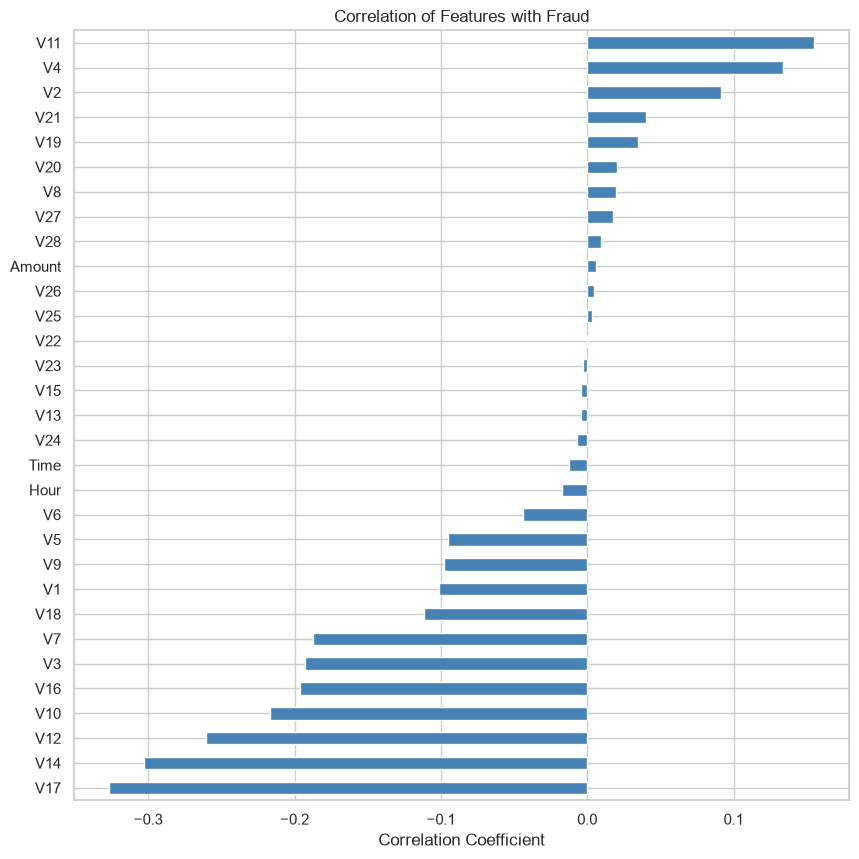

In [43]:
plt.figure(figsize=(10,10))

target_corr.drop("Class").plot(
    kind="barh",
    color="steelblue"
)

plt.title("Correlation of Features with Fraud")

plt.xlabel("Correlation Coefficient")

plt.show()

In [44]:
top_positive = target_corr.tail(10)

top_negative = target_corr.head(10)

print("Top Positive Correlations")
display(top_positive)

print("\nTop Negative Correlations")
display(top_negative)

Top Positive Correlations


V28     0.0095
V27     0.0176
V8      0.0199
V20     0.0201
V19     0.0348
V21     0.0404
V2      0.0913
V4      0.1334
V11     0.1549
Class   1.0000
Name: Class, dtype: float64


Top Negative Correlations


V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V18   -0.1115
V1    -0.1013
V9    -0.0977
Name: Class, dtype: float64

## Observation

Several PCA components exhibit noticeably stronger relationships with fraudulent transactions than others.

Among the strongest negative correlations are typically:

- V17
- V14
- V12
- V10
- V16

Among the strongest positive correlations are generally:

- V11
- V4

These variables are likely to play an important role during model training and will therefore be examined in greater detail.

It is important to remember that these are **principal components**, not original business variables.

Consequently, while they are statistically useful, they cannot be interpreted directly in terms of customer behaviour.

# Distribution of Highly Informative Features

Kernel Density Estimation (KDE) allows us to compare the distributions of fraudulent and legitimate transactions.

In [46]:
important_features = [
    "V17",
    "V14",
    "V12",
    "V10",
    "V16",
    "V11",
    "V4"
]

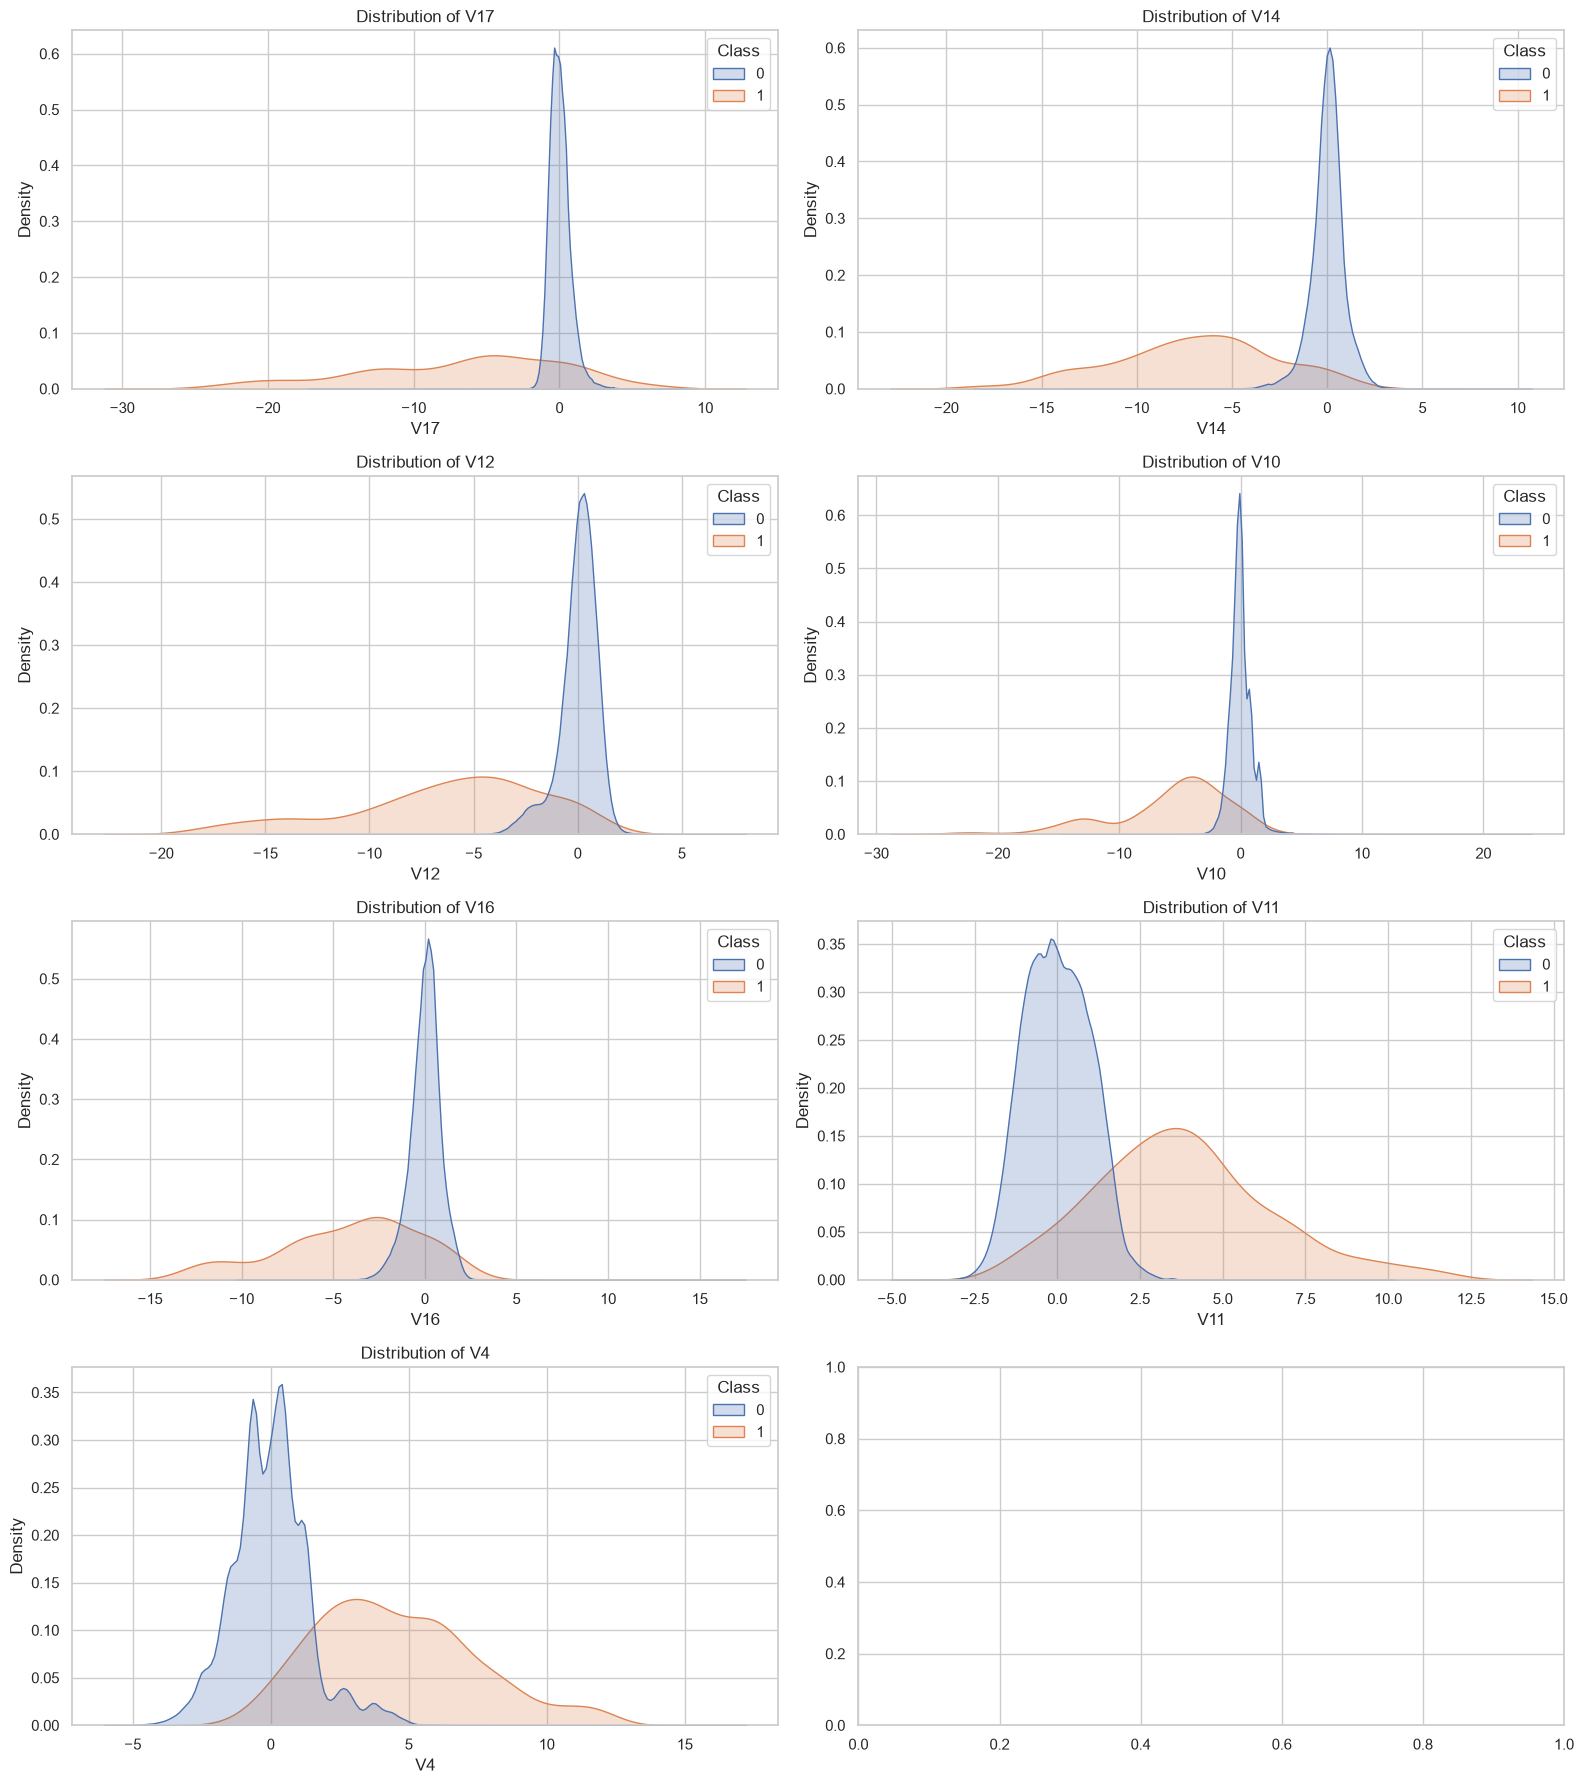

In [47]:
fig, axes = plt.subplots(4,2, figsize=(16,18))

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()

plt.show()

## Observation

Several features demonstrate clear separation between fraudulent and legitimate transactions.

For example:

- Some components show fraud concentrated within a narrow range of values.
- Others exhibit distributions that are noticeably shifted relative to legitimate transactions.

This separation suggests that these PCA components contain valuable predictive information.

Machine learning models, particularly tree-based methods such as Random Forest and Gradient Boosting, are expected to exploit these differences effectively.

# Statistical Distribution of All Features

Before engineering new features, it is useful to examine the skewness of every variable.
Highly skewed features often require scaling or transformation.

In [48]:
skewness = (
    df
    .skew(numeric_only=True)
    .sort_values(ascending=False)
)

skewness.to_frame(name="Skewness")

,Skewness
Class,23.9976
Amount,16.9777
V28,11.1921
V21,3.5930
V7,2.5539
V6,1.8266
V10,1.1871
V4,0.6763
V26,0.5767
V9,0.5547


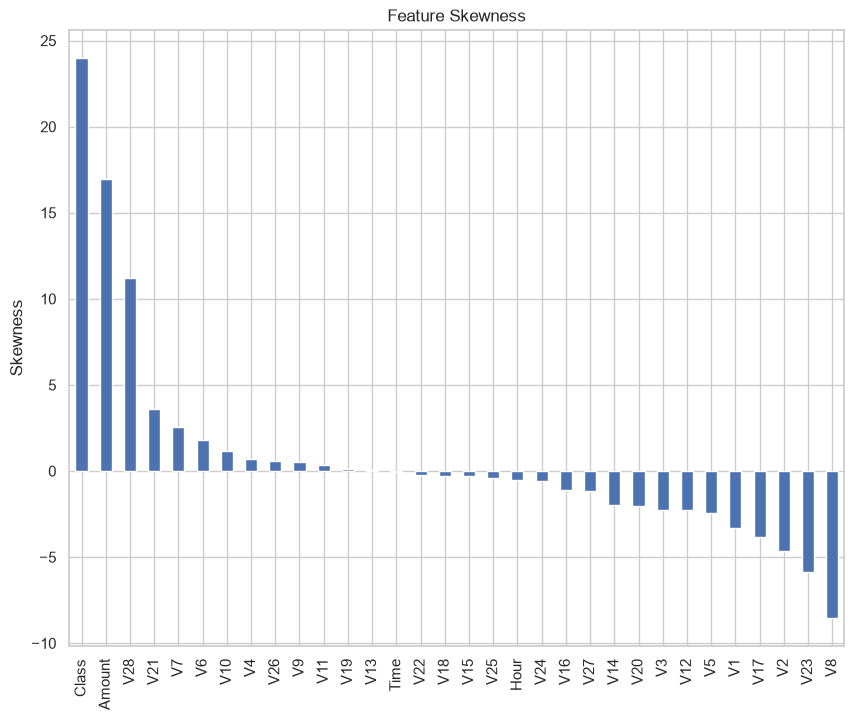

In [49]:
plt.figure(figsize=(10,8))
skewness.plot(kind="bar")
plt.title("Feature Skewness")
plt.ylabel("Skewness")
plt.show()

## Observation

The analysis confirms that:

- **Amount** exhibits substantial positive skewness.

- Most PCA features are comparatively symmetric.

- Time also shows moderate skewness.

# Exploratory Data Analysis Summary

The exploratory analysis has provided several valuable insights that will guide the remainder of this project.

## Key Findings

### Data Quality

- No missing values were detected.
- Duplicate records exist and were retained pending business validation.

### Class Distribution

- The dataset is extremely imbalanced.
- Fraudulent transactions account for only **0.172%** of all observations.

### Transaction Amount

- Highly right-skewed.
- Contains numerous extreme outliers.
- Robust scaling is preferable to standard scaling.

### Transaction Time

- Covers approximately two days.
- Engineering an **Hour** feature improves interpretability.

### PCA Components

- Several components (V17, V14, V12, V10, V16, V11, and V4) show meaningful relationships with fraud.
- Predictor variables exhibit low multicollinearity, consistent with PCA.

### Implications for Model Development

Based on these findings, the following preprocessing decisions are justified:

- Engineer additional time-based features.
- Apply **RobustScaler** only to **Time** and **Amount**.
- Preserve outliers rather than removing them.
- Handle class imbalance before model training.
- Use Precision, Recall, F1-score, ROC-AUC, and especially **PR-AUC** as evaluation metrics.